In [ ]:
# import necessary libraries
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.features import rasterize
from pyproj import Transformer
import pystac_client
import xarray as xr
import warnings
warnings.filterwarnings('ignore')
import odc.stac

In [50]:
def load_and_reproject_polygon(geojson_file_path, target_epsg, wgs_epsg=4326):
    """
    Load GeoJSON polygon and reproject to UTM zone
    
    Args:
        geojson_file_path: Path to GeoJSON file
        target_epsg: Target EPSG code (default: 4326 )
    
    Returns:
        GeoDataFrame with reprojected geometry, bbox for STAC query
    """
    # Load GeoJSON
    gdf = gpd.read_file(geojson_file_path)
    
    # Ensure CRS is set (assume WGS84 if not specified)
    if gdf.crs is None:
        gdf.crs = f"EPSG:{wgs_epsg}"
    
    # Reproject to UTM
    gdf_utm = gdf.to_crs(f"EPSG:{target_epsg}")
    # Reproject to WGS84
    gdf_wgs = gdf.to_crs(f"EPSG:{wgs_epsg}")
    
    # Get bounds for STAC query (must remain in WGS84)
    bounds_wgs84 = gdf_wgs.bounds.iloc[0]
    bbox = [bounds_wgs84.minx, bounds_wgs84.miny, bounds_wgs84.maxx, bounds_wgs84.maxy]
    
    return gdf_utm, bbox


In [51]:
def query_sentinel2_data(bbox, start_date, end_date, cloud_cover_threshold=30):
    """
    Query Sentinel-2 L2A data from Element84 Earth Search API
    
    Args:
        bbox: Bounding box [minx, miny, maxx, maxy] in WGS84
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
        cloud_cover_threshold: Maximum cloud cover percentage
    
    Returns:
        STAC items collection
    """
    # Connect to Element84 Earth Search API
    catalog = pystac_client.Client.open("https://earth-search.aws.element84.com/v1")
    
    # Search for Sentinel-2 L2A data
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=f"{start_date}/{end_date}",
        query={"eo:cloud_cover": {"lt": cloud_cover_threshold}}
    )
    
    items = search.item_collection()
    print(f"Found {len(items)} Sentinel-2 scenes")
    
    return items


In [ ]:
def calculate_ndci_timeseries(items, bbox, target_epsg=32644):
    """
    Calculate NDCI time series for polygon area
    
    Args:
        items: STAC items collection
        bbox: bounding box in lat lon
        polygon_gdf: GeoDataFrame with polygon geometry in target CRS
        target_epsg: Target EPSG code
    
    Returns:
        DataFrame with NDCI time series
    """
    ndci_results = []
    
    for item in items:
        try:
            # Load B04 and B05 bands at 20m resolution
            data = odc.stac.load(
                [item],
                bands=["red","rededge1", "scl","green","swir16"],
                crs=target_epsg,
                bbox =bbox,
                resolution=20,
                chunks={'x':2048,'y':2048},
            )
            
            # Load data into memory
            #data = stack.compute()
            
            # Extract bands
            b04 = data["red"].values[0]  # Red band
            b05 = data["rededge1"].values[0]  # Red-edge band
            scl = data["scl"].values[0]  # Scene classification
            
            # Create water mask using SCL (class 6 = water)
            water_mask = (scl == 6)
            
            green = data["green"].values[0]
            swir = data["swir16"].values[0]
             # Calculate MNDWI for additional water detection

            # Calculate MNDWI: (Green - SWIR) / (Green + SWIR)
            mndwi = (green - swir) / (green + swir + 1e-8)
            additional_water_mask = mndwi > 0.3
            
            # Combine water masks
            combined_water_mask = water_mask | additional_water_mask
            
            # Calculate NDCI: (B05 - B04) / (B05 + B04)
            ndci = (b05 - b04) / (b05 + b04 + 1e-8)
            
            # Apply masks
            valid_mask = combined_water_mask & ~np.isnan(ndci)
            
            if (valid_mask.sum() > 0):
                # Calculate spatial average NDCI for water pixels within polygon
                mean_ndci = np.mean(ndci[valid_mask])
                pixel_count = valid_mask.sum()
                
                # Get image date
                image_date = pd.to_datetime(item.properties['datetime'])
                
                ndci_results.append({
                    'date': image_date,
                    'ndci': mean_ndci,
                    'pixel_count': pixel_count,
                    'scene_id': item.id
                })
                
        except Exception as e:
            print(f"Error processing {item.id}: {str(e)}")
            continue
    
    # Convert to DataFrame and sort by date
    df = pd.DataFrame(ndci_results)
    df = df.sort_values('date').reset_index(drop=True)
    
    return df


In [57]:
def create_ndci_timeseries_plot(df, title="NDCI Time Series"):
    """
    Create NDCI time series plot with seasonal indicators
    
    Args:
        df: DataFrame with NDCI time series data
        title: Plot title
    
    Returns:
        matplotlib figure object
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot NDCI time series
    ax1.plot(df['date'], df['ndci'], 'b-o', linewidth=2, markersize=4)
    ax1.set_ylabel('NDCI Value', fontsize=12)
    ax1.set_title(title, fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    
    # Add seasonal indicators
    ax1.axhline(y=0.2, color='orange', linestyle='--', alpha=0.7, label='Moderate chlorophyll')
    ax1.axhline(y=0.3, color='red', linestyle='--', alpha=0.7, label='High chlorophyll')
    ax1.legend()
    
    # Plot pixel count
    ax2.bar(df['date'], df['pixel_count'], alpha=0.7, color='green')
    ax2.set_ylabel('Valid Pixels', fontsize=12)
    ax2.set_xlabel('Date', fontsize=12)
    ax2.grid(True, alpha=0.3)
    
    # Format x-axis
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    return fig


In [58]:
def main_workflow(geojson_file, start_date, end_date, target_epsg=32644):
    """
    Main workflow function for NDCI time series analysis
    
    Args:
        geojson_file: Path to GeoJSON file
        start_date: Start date (YYYY-MM-DD)
        end_date: End date (YYYY-MM-DD)
        target_epsg: Target EPSG code
    
    Returns:
        DataFrame with NDCI time series results
    """
    print("Step 1: Loading and reprojecting polygon...")
    polygon_gdf, bbox = load_and_reproject_polygon(geojson_file, target_epsg)
    
    print("Step 2: Querying Sentinel-2 data...")
    items = query_sentinel2_data(bbox, start_date, end_date)
    
    print("Step 3: Calculating NDCI time series...")
    ndci_df = calculate_ndci_timeseries(items, bbox, target_epsg)
    
    print("Step 4: Creating visualization...")
    fig = create_ndci_timeseries_plot(ndci_df, "Pond NDCI Time Series")
    
    print("Step 5: Saving results...")
    ndci_df.to_csv('ndci_timeseries.csv', index=False)
    fig.savefig('ndci_timeseries.png', dpi=300, bbox_inches='tight')
    
    print("Analysis complete!")
    return ndci_df


Step 1: Loading and reprojecting polygon...
Step 2: Querying Sentinel-2 data...
Found 57 Sentinel-2 scenes
Step 3: Calculating NDCI time series...
Step 4: Creating visualization...
Step 5: Saving results...
Analysis complete!


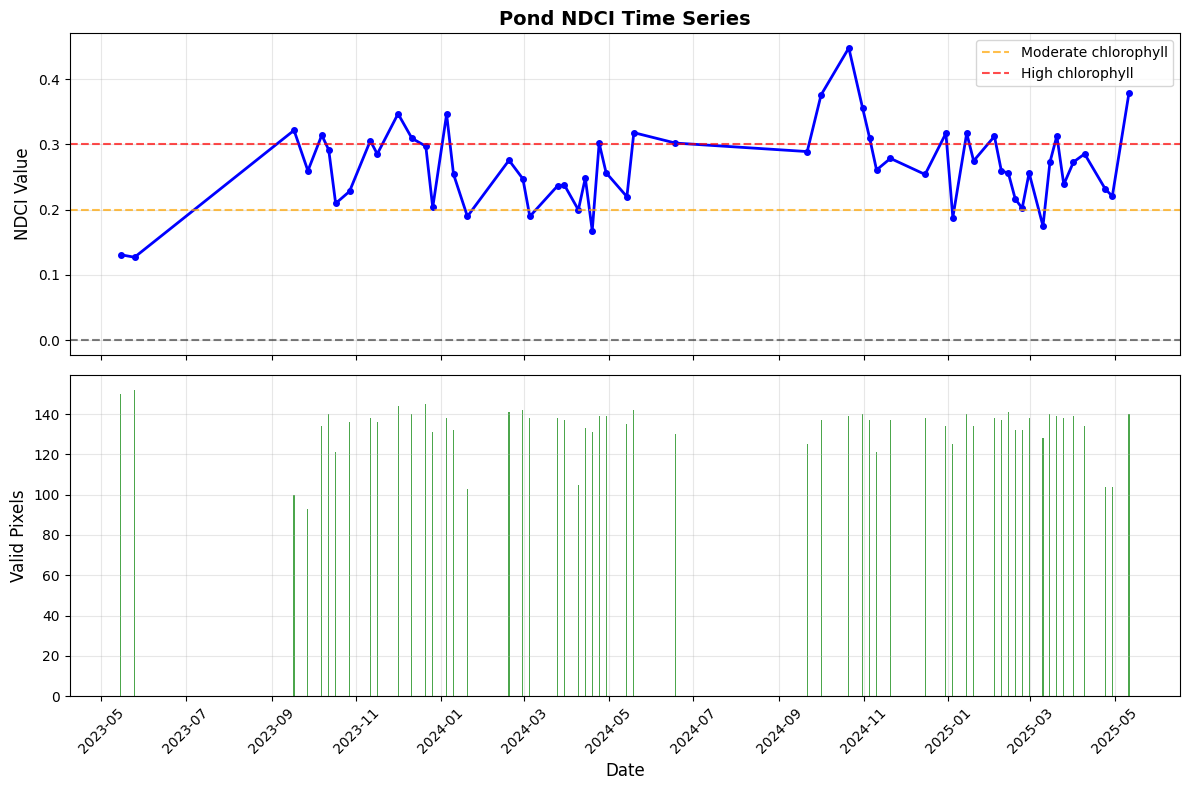

In [60]:
if __name__ == "__main__":
    
    # Run analysis
    ndci_df = main_workflow(
        geojson_file='data/snr1.geojson',
        start_date='2023-05-01',
        end_date='2025-05-31',
        target_epsg=32644
    )